## Проверка решений уравнений вида $y''=f(x,y,y')$ численным методом для n=32

In [13]:
import matplotlib.pyplot as plt
from problems.boundary_conditions import BoundaryCondition
from problems.nonlin_gen import ODENewton
import numpy as np
import math

---

В первом ноутбуке решали тестовый пример, который очень хорошо сошелся. Теперь возьмем несколько других задач, и посмотрим, решатся ли они так же хорошо

---

# Первое уравнение (тангенс)
$$\begin{cases}
y'' = 2y(1 + y^2), \\
y(0) = 0, \quad y(1) = \tan(1)
\end{cases}$$


аналитически: $y = tan(x) $


In [44]:
def myfunc(x, y, dy):
    return 2*y*(1+y**2)


n = 32   # колво точек
y0 = 0   # значение в x=0
y1 = math.tan(1)   # значение в x=1
bc = BoundaryCondition(-1, -1, y0, y1)
taktak = ODENewton(myfunc, bc)
taktak.solve(n)

True

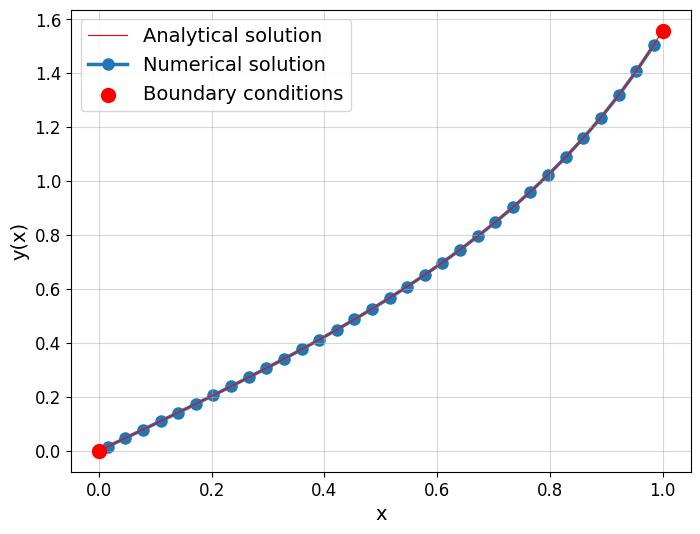

[0.01562277 0.04689883 0.07826669 0.10978835 0.14152702 0.17354765
 0.20591746 0.23870649 0.27198832 0.30584067 0.34034624 0.37559356
 0.41167794 0.44870264 0.48678017 0.52603372 0.56659898 0.60862614
 0.65228236 0.69775462 0.74525317 0.79501572 0.84731247 0.90245224
 0.96079012 1.0227368  1.08877043 1.15945135 1.23544114 1.31752685
 1.40665277 1.50396221]
итераций: 2


In [45]:
y_1 = taktak.get_solution()
x_1 = taktak.x_grid
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = np.tan(nd_fine)
plt.plot(nd_fine, rel_sol, color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o', lw=2.5, ms=8, label="Numerical solution", zorder=1)
plt.scatter((0, 1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()
print(y_1)
plt.show()
print( "итераций:", taktak.iter_needed)

СОШЛОСЬ

# Пример 2
$$\begin{cases}
y'' = -\frac{2(y')^2}{y}, \quad x \in [1, 2] \\
y(1) = 1, \quad y(2) = 1
\end{cases}$$

аналитическое решение:$$y(x) = \sqrt[3]{1 + 6(x-1)(2-x)}$$

In [46]:
def myfunc(x, y, dy):
    return -3.0 / (y**3)


n = 32   # колво точек
y0 = 1   # значение в x=0
y1 = 1   # значение в x=1
bc = BoundaryCondition(-1, -1, y0, y1)
taktak = ODENewton(myfunc, bc)
taktak.solve(n)

True

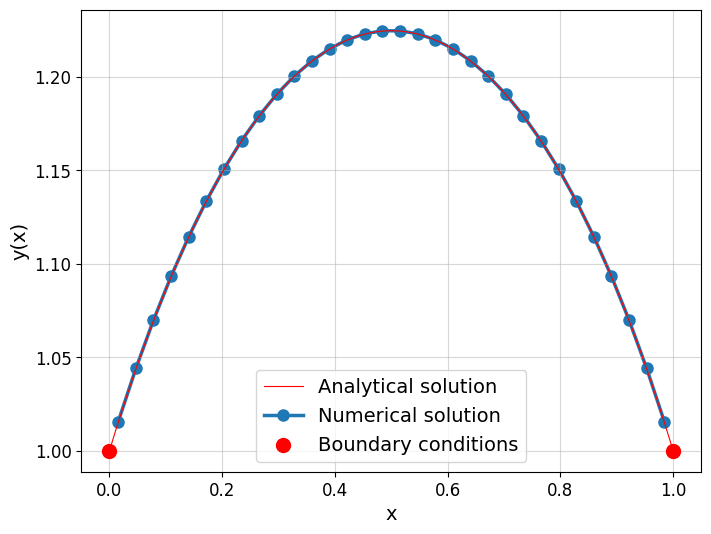

[1.01561002 1.04403339 1.06988234 1.09333902 1.11455409 1.13365316
 1.15074137 1.16590699 1.17922406 1.19075452 1.20054975 1.20865189
 1.21509475 1.2199046  1.22310068 1.22469559 1.22469559 1.22310068
 1.2199046  1.21509475 1.20865189 1.20054975 1.19075452 1.17922406
 1.16590699 1.15074137 1.13365316 1.11455409 1.09333902 1.06988234
 1.04403339 1.01561002]
итераций: 3


In [47]:
y_1 = taktak.get_solution()
x_1 = taktak.x_grid
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = np.sqrt(1.0 + 2.0 * nd_fine * (1.0 - nd_fine))
plt.plot(nd_fine, rel_sol, color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o', lw=2.5, ms=8, label="Numerical solution", zorder=1)
plt.scatter((0, 1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()
print(y_1)
plt.show()
print( "итераций:", taktak.iter_needed)

# Пример 3 (экспонента)
$$  \begin{cases}
  y'' = e^{2y}, \quad x \in [0, 1] \\
  y(0) = 0, \quad y(1) = -\ln(2) \approx -0.6931
  \end{cases}$$


  аналитическое решение: $$y(x) = -\ln(x + 1)$$

In [48]:
def myfunc(x, y, dy):
    return np.exp(2 * y)

n = 32   # колво точек
y0 = 0   # значение в x=0
y1 = -np.log(2)  # значение в x=1
bc = BoundaryCondition(-1, -1, y0, y1)
taktak = ODENewton(myfunc, bc)
taktak.solve(n)

True

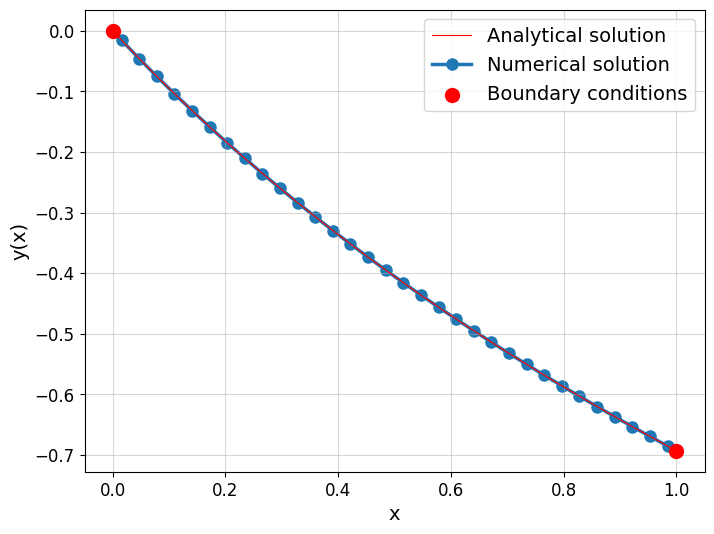

[-0.01562246 -0.04592085 -0.07532838 -0.10389592 -0.13167013 -0.15869387
 -0.18500662 -0.21064484 -0.23564224 -0.26003006 -0.28383734 -0.30709106
 -0.32981638 -0.35203677 -0.37377419 -0.39504918 -0.41588101 -0.43628776
 -0.45628642 -0.47589301 -0.4951226  -0.5139894  -0.53250686 -0.55068768
 -0.56854388 -0.58608684 -0.60332736 -0.62027571 -0.6369416  -0.65333431
 -0.66946265 -0.685335  ]
итераций: 1


In [49]:
y_1 = taktak.get_solution()
x_1 = taktak.x_grid
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = -np.log(nd_fine+1)
plt.plot(nd_fine, rel_sol, color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o', lw=2.5, ms=8, label="Numerical solution", zorder=1)
plt.scatter((0, 1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()
print(y_1)
plt.show()
print( "итераций:", taktak.iter_needed)

# 4 скоростной осциллятор
$$  \begin{cases}
  y'' = -64y, \quad x \in [0, 1] \\
  y(0) = 0, \quad y(1) = \pi \approx 3.14159
  \end{cases}$$
  аналитического решения вроде нет


In [54]:
def myfunc(x, y, dy):
    return -64*y


n = 50   # колво точек
y0 = 0   # значение в x=0
y1 = np.sin(8.0)   # значение в x=1
bc = BoundaryCondition(-1, -1, y0, y1)
taktak = ODENewton(myfunc, bc)
taktak.solve(n)

True

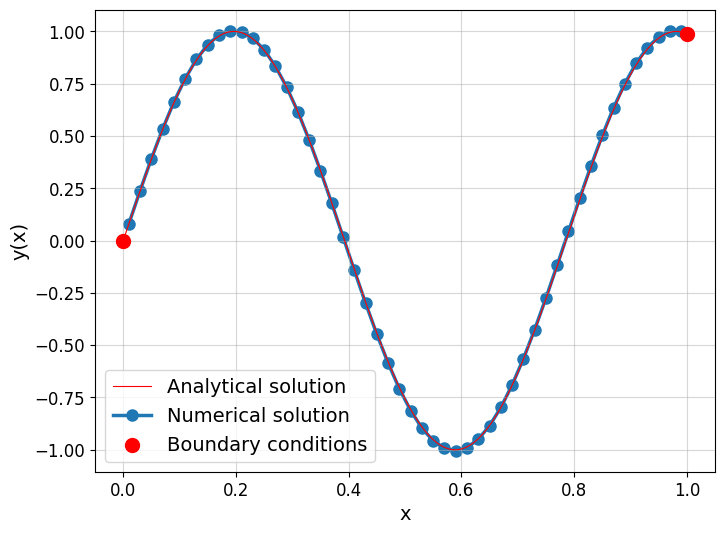

[ 0.08036132  0.23902671  0.39157301  0.53409504  0.66294424  0.77482207
  0.86686446  0.93671511  0.98258586  1.00330241  0.99833441  0.96780906
  0.91250779  0.83384633  0.7338384   0.6150442   0.48050488  0.33366463
  0.17828256  0.01833646 -0.14207905 -0.29885734 -0.44798488 -0.58564401
 -0.70831065 -0.81284454 -0.8965696  -0.95734249 -0.99360741 -1.00443598
 -0.98955099 -0.94933349 -0.88481305 -0.79764141 -0.69005014 -0.56479359
 -0.42507832 -0.27448104 -0.11685706  0.04375847  0.20325378  0.3575458
  0.50268464  0.63495475  0.75097003  0.84776047  0.92284824  0.9743111
  1.00083159  1.0017308 ]
итераций: 0


In [56]:
y_1 = taktak.get_solution()
x_1 = taktak.x_grid
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = np.sin(nd_fine*8)
plt.plot(nd_fine, rel_sol, color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o', lw=2.5, ms=8, label="Numerical solution", zorder=1)
plt.scatter((0, 1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()
print(y_1)
plt.show()
print( "итераций:", taktak.iter_needed)

Для данных уравнений код сходится за странно малое число итераций, не понимаю причину